Dataset ke pehle 5 rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

R2 Score: 0.8994
RMSE: 1.7816


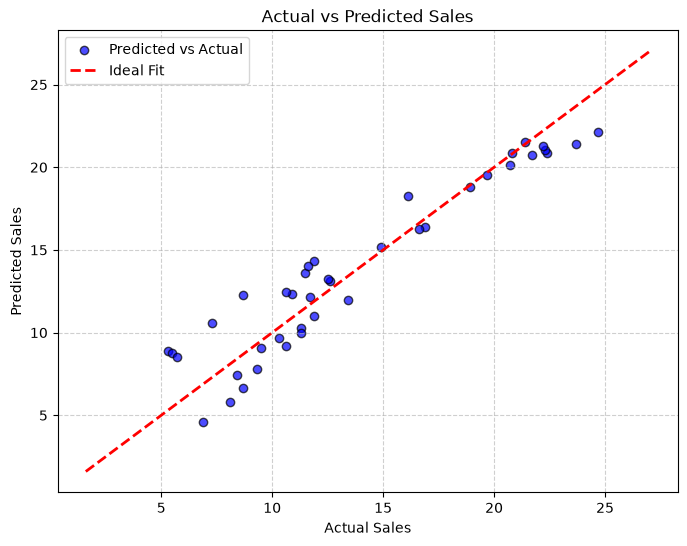

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Dataset
df = pd.read_csv('Advertising.csv')
print("Dataset ke pehle 5 rows:")
print(df.head())

# 2. Define Features (X) and Target (y)
# (Note: Agar pehla column 'Unnamed: 0' ya index hai toh use drop kar sakte hain)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 3. Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predictions & Evaluation
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# 6. Plotting Actual vs Predicted Sales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.7, label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig('sales_actual_vs_predicted.png')
plt.show()